In [1]:
from openff.toolkit import ForceField, Molecule

In [2]:
ff = ForceField("openff_no_water-3.0.0-alpha0.offxml")

## Hidden section

In [3]:
from typing import Union, Optional, List, Dict, Iterable, Tuple
import uuid
from io import StringIO
from numpy.typing import NDArray

import rdkit.Chem
import rdkit.Chem.rdDepictor
import rdkit.Chem.Draw
from IPython.display import SVG
import nglview
from nglview.base_adaptor import Structure, Trajectory

from openff.units import ensure_quantity
import mdtraj
import numpy
import nglview
from pathlib import Path
from openmm.app import PDBFile
import openmm

from openff.toolkit import Molecule, Topology
from openff.units import unit

DEFAULT_WIDTH = 400
DEFAULT_HEIGHT = 300

Color = Iterable[float]
BondIndices = Tuple[int, int]

def draw_molecule(
    molecule: Union[Molecule, rdkit.Chem.rdchem.Mol],
    *,
    width: int = DEFAULT_WIDTH,
    height: int = DEFAULT_HEIGHT,
    highlight_atoms: Optional[Union[List[int], Dict[int, Color]]] = None,
    highlight_bonds: Optional[
        Union[List[BondIndices], Dict[BondIndices, Color]]
    ] = None,
    atom_notes: Optional[Dict[int, str]] = None,
    bond_notes: Optional[Dict[BondIndices, str]] = None,
    emphasize_atoms: Optional[List[int]] = None,
    explicit_hydrogens: Optional[bool] = None,
    color_by_element: Optional[bool] = None,
) -> SVG:
    """Draw a molecule

    Parameters
    ==========

    molecule
        The molecule to draw.
    image_width
        The width of the resulting image in pixels.
    image_height
        The height of the resulting image in pixels.
    highlight_atoms
        A list of atom indices to highlight, or a map from indices to colors.
        Colors should be given as triplets of floats between 0.0 and 1.0.
    highlight_bonds
        A list of pairs of atom indices indicating bonds to highlight, or a map
        from index pairs to colors. Colors should be given as triplets of floats
        between 0.0 and 1.0.
    atom_notes
        A map from atom indices to a string that should be printed near the
        atom.
    bond_notes
        A map from atom index pairs to a string that should be printed near the
        bond.
    emphasize_atoms
        A list of atom indices to emphasize by drawing other atoms (and their
        bonds) in light grey.
    explicit_hydrogens
        If ``False``, allow uncharged monovalent hydrogens to be hidden. If
        ``True``, make all hydrogens explicit. If ``None``, defer to the
        provided molecule.
    color_by_element
        If True, color heteroatoms according to their element; if False, color
        atoms and bonds monochromatically. By default, uses black and white when
        highlight_atoms or highlight_bonds is provided, and color otherwise.

    Raises
    ======

    KeyError
        When an atom or bond in highlight_atoms or highlight_bonds is missing
        from the image, including when it is present in the molecule but hidden.
    """
    # We're working in RDKit
    try:
        rdmol = molecule.to_rdkit()
    except AttributeError:
        rdmol = rdkit.Chem.rdchem.Mol(molecule)

    # Process color_by_element argument
    if color_by_element is None:
        color_by_element = highlight_atoms is None and highlight_bonds is None

    if color_by_element:
        set_atom_palette = lambda draw_options: draw_options.useDefaultAtomPalette()
    else:
        set_atom_palette = lambda draw_options: draw_options.useBWAtomPalette()

    # Process explicit_hydrogens argument
    # If we need to remove atoms, create a map from the original indices to the
    # new ones.
    if explicit_hydrogens is None:
        idx_map = {i: i for i in range(rdmol.GetNumAtoms())}
    elif explicit_hydrogens:
        idx_map = {i: i for i in range(rdmol.GetNumAtoms())}
        rdmol = rdkit.Chem.AddHs(rdmol, explicitOnly=True)
    else:
        idx_map = {
            old: new
            for new, old in enumerate(
                a.GetIdx()
                for a in rdmol.GetAtoms()
                if a.GetAtomicNum() != 1 and a.GetMass() != 1
            )
        }
        rdmol = rdkit.Chem.RemoveHs(rdmol, updateExplicitCount=True)

    # Process highlight_atoms argument for highlightAtoms and highlightAtomColors
    # highlightAtoms takes a list of atom indices
    # highlightAtomColors takes a mapping from atom indices to colors
    if highlight_atoms is None:
        highlight_atoms = []
        highlight_atom_colors = None
    elif isinstance(highlight_atoms, dict):
        highlight_atom_colors = {
            idx_map[i]: tuple(c) for i, c in highlight_atoms.items() if i in idx_map
        }
        highlight_atoms = list(highlight_atoms.keys())
    else:
        highlight_atoms = [idx_map[i] for i in highlight_atoms if i in idx_map]
        highlight_atom_colors = None

    # Process highlight_bonds argument for highlightBonds and highlightBondColors
    # highlightBonds takes a list of bond indices
    # highlightBondColors takes a mapping from bond indices to colors
    if highlight_bonds is None:
        highlight_bonds = []
        highlight_bond_colors = None
    elif isinstance(highlight_bonds, dict):
        highlight_bond_colors = {
            rdmol.GetBondBetweenAtoms(idx_map[i_a], idx_map[i_b]).GetIdx(): tuple(v)
            for (i_a, i_b), v in highlight_bonds.items()
            if i_a in idx_map and i_b in idx_map
        }

        highlight_bonds = list(highlight_bond_colors.keys())
    else:
        highlight_bonds = [
            rdmol.GetBondBetweenAtoms(idx_map[i_a], idx_map[i_b]).GetIdx()
            for i_a, i_b in highlight_bonds
            if i_a in idx_map and i_b in idx_map
        ]
        highlight_bond_colors = None

    # Process bond_notes argument and place notes in the molecule
    if bond_notes is not None:
        for (i_a, i_b), note in bond_notes.items():
            if i_a not in idx_map or i_b not in idx_map:
                continue
            rdbond = rdmol.GetBondBetweenAtoms(idx_map[i_a], idx_map[i_b])
            rdbond.SetProp("bondNote", unicode_to_ascii(str(note)))

    # Process atom_notes argument and place notes in the molecule
    if atom_notes is not None:
        for i, note in atom_notes.items():
            if i not in idx_map:
                continue
            rdatom = rdmol.GetAtomWithIdx(idx_map[i])
            rdatom.SetProp("atomNote", unicode_to_ascii(str(note)))

    # Resolve kekulization so it is the same for all drawn molecules
    rdkit.Chem.rdmolops.Kekulize(rdmol, clearAromaticFlags=True)

    # Compute 2D coordinates
    rdkit.Chem.rdDepictor.SetPreferCoordGen(True)
    rdkit.Chem.rdDepictor.Compute2DCoords(rdmol)

    # Construct the drawing object and get a handle to its options
    drawer = rdkit.Chem.Draw.MolDraw2DSVG(width, height)
    draw_options = drawer.drawOptions()

    # Specify the scale to fit all atoms
    # This is important for emphasize_atoms
    coords_2d = next(rdmol.GetConformers()).GetPositions()[..., (0, 1)]
    drawer.SetScale(
        width,
        height,
        rdkit.Geometry.rdGeometry.Point2D(*(coords_2d.min(axis=0) - 1.0)),
        rdkit.Geometry.rdGeometry.Point2D(*(coords_2d.max(axis=0) + 1.0)),
    )

    # Set the colors used for each element according to the emphasize_atoms and
    # color_by_element arguments
    if emphasize_atoms:
        draw_options.setAtomPalette(
            {i: (0.8, 0.8, 0.8) for i in range(rdmol.GetNumAtoms())}
        )
    else:
        set_atom_palette(draw_options)

    # Draw the molecule
    # Note that if emphasize_atoms is used, this will be the un-emphasized parts
    # of the molecule
    drawer.DrawMolecule(
        rdmol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_atom_colors,
        highlightBonds=highlight_bonds,
        highlightBondColors=highlight_bond_colors,
    )

    # Draw an overlapping molecule for the emphasized atoms
    if emphasize_atoms:
        # Set the atom palette according to the color_by_element argument
        set_atom_palette(draw_options)

        # Create a copy of the molecule that removes atoms that aren't emphasized
        emphasized = rdkit.Chem.rdchem.RWMol(rdmol)
        emphasized.BeginBatchEdit()
        for i in set(idx_map) - set(emphasize_atoms):
            emphasized.RemoveAtom(idx_map[i])
        emphasized.CommitBatchEdit()

        # Draw the molecule. The scale has been fixed and we're re-using the
        # same coordinates, so this will overlap the background molecule
        drawer.DrawMolecule(emphasized)

    # Finalize the SVG
    drawer.FinishDrawing()

    # Return an SVG object that we can view in notebook
    svg_contents = drawer.GetDrawingText()
    return SVG(svg_contents)

## Not hidden section

In [7]:
def draw_molecule(
    molecule: Union[Molecule, rdkit.Chem.rdchem.Mol],
    *,
    width: int = DEFAULT_WIDTH,
    height: int = DEFAULT_HEIGHT,
    highlight_atoms: Optional[Union[List[int], Dict[int, Color]]] = None,
    highlight_bonds: Optional[
        Union[List[BondIndices], Dict[BondIndices, Color]]
    ] = None,
    atom_notes: Optional[Dict[int, str]] = None,
    bond_notes: Optional[Dict[BondIndices, str]] = None,
    emphasize_atoms: Optional[List[int]] = None,
    explicit_hydrogens: Optional[bool] = None,
    color_by_element: Optional[bool] = None,
) -> SVG:


_IncompleteInputError: incomplete input (1507800732.py, line 15)

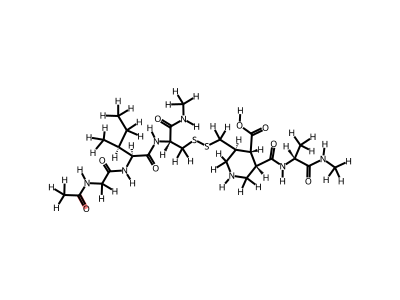

In [9]:
#mol = Molecule.from_smiles("CNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)[O-]")
#mol = Molecule.from_smiles("CC(=O)N[C@@]([H])(C)C(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)NCC(=O)N[C@@]([H])(CCC(=O)N)C(=O)N[C@@]([H])(CCCNC(=N)N)C(=O)N[C@@]([H])(CC1=CN=C-N1)C(=O)NC", allow_undefined_stereo=True)
#mol = Molecule.from_smiles("CC(=O)N[C@@]([H])(C)C(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)NCC(=O)N[C@@]([H])(CCC(=O)N)C(=O)NC", allow_undefined_stereo=True)

# GIA
#mol = Molecule.from_smiles("CC(=O)NCC(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)N[C@@]([H])(C)C(=O)NC")

# GIAC+PTM
#mol = Molecule.from_smiles("CC(=O)NCC(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)N[C@@]([H])(C)C(=O)N[C@@]([H])(CSSC[C@H]1[C@H](C(=O)(O))[C@H](C(=O)NCC(=O)N[C@H](C)C(=O)NC)(CNC1))C(=O)NC")

# GIC
#mol = Molecule.from_smiles("CC(=O)NCC(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)N[C@@]([H])(CS)C(=O)NC")

# GIC+PTM
mol = Molecule.from_smiles("CC(=O)NCC(=O)N[C@@]([H])([C@]([H])(CC)C)C(=O)N[C@@]([H])(CSSC[C@H]1[C@H](C(=O)(O))[C@H](C(=O)N[C@H](C)C(=O)NC)(CNC1))C(=O)NC")


#mol.generate_conformers()
draw_molecule(mol, highlight_bonds=[(1,2)])

## FF.label_molecules based

In [10]:
labels = ff.label_molecules(mol.to_topology())


(1, 3, 4, 5)
Protein-phi-general
(3, 4, 5, 7)
Protein-psi-general
(5, 7, 8, 10)
Protein-phi-beta-branched
(5, 7, 8, 15)
Protein-phi-general
(7, 8, 15, 17)
Protein-psi-general
(10, 8, 15, 17)
Protein-psi-beta-branched
(15, 17, 18, 20)
Protein-phi-sidechain
(15, 17, 18, 42)
Protein-phi-general
(17, 18, 42, 44)
Protein-psi-general
(20, 18, 42, 44)
Protein-psi-sidechain
(30, 32, 33, 34)
Protein-phi-sidechain
(30, 32, 33, 35)
Protein-phi-general
(32, 33, 35, 37)
Protein-psi-general
(34, 33, 35, 37)
Protein-psi-sidechain


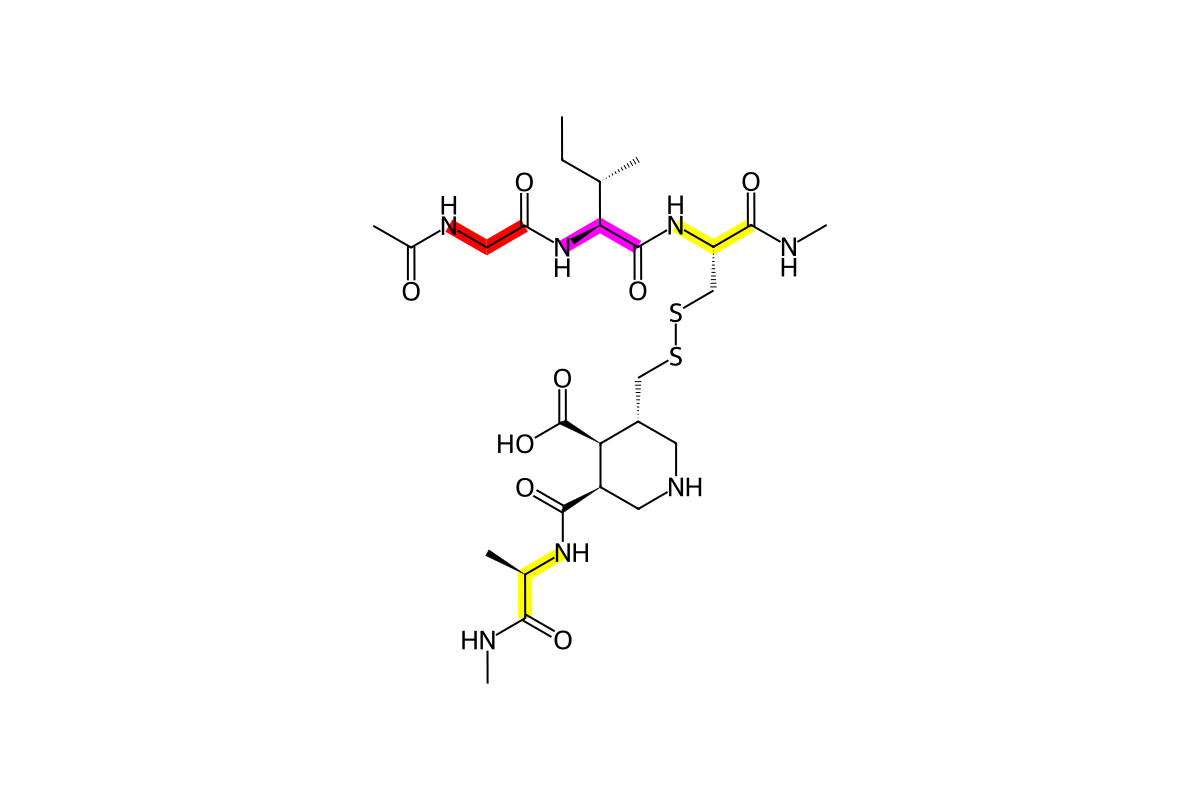

In [11]:
import numpy as np
pt_labels = labels[0]['ProperTorsions']
highlight_bonds = []
highlight_bonds_dict = {}
#colors = []
for key,val in pt_labels.items():
    if "Protein" in val.id:
        print(key)
        print(val.id)
        color = None
        if "general" in val.id:
            color = np.array([1,0,0])
        elif "sidechain" in val.id:
            color = np.array([0,1,0])
        elif "beta" in val.id:
            color = np.array([0,0,1])
        highlight_bonds.append((key[1], key[2]))
        highlight_bonds_dict[(key[1], key[2])] = highlight_bonds_dict.get((key[1], key[2]), np.array([0., 0., 0.,])) + color
draw_molecule(mol, 
              width=1200, height=800,
              #highlight_bonds=highlight_bonds,
              highlight_bonds = highlight_bonds_dict,
              explicit_hydrogens=False
              )
    #print(key, val.id)
    #param = 
    

In [ ]:
highlight_bonds_dict
# [#6X4]-[#6X3:1](=[#8])-[#7X3:2]-[#6X4:3]-[#6X3:4](=[#8])-[#7X3]-[#6X4] #phi general
# [#6X4]-[#6X3](=[#8])-[#7X3:1]-[#6X4:2]-[#6X3:3](=[#8])-[#7X3:4]-[#6X4] # psi general
# [#6X4]-[#6X3:1](=[#8])-[#7X3:2]-[#6X4:3](-[#6X3](=[#8])-[#7X3]-[#6X4])-[#6X4:4] #phi sidechain
# [#6X4]-[#6X3](=[#8])-[#7X3]-[#6X4:2](-[#6X3:3](=[#8])-[#7X3:4]-[#6X4])-[#6X4:1] # psi sidechain
# [#6X4]-[#6X3:1](=[#8])-[#7X3:2]-[#6X4:3](-[#6X3](=[#8])-[#7X3]-[#6X4])-[#6X4:4](-[!X1])-[!X1] #phi beta
# [#6X4]-[#6X3](=[#8])-[#7X3]-[#6X4:2](-[#6X3:3](=[#8])-[#7X3:4]-[#6X4])-[#6X4:1](-[!X1])-[!X1] #psi beta


In [15]:
mol.generate_conformers()
mol.visualize(backend='nglview')

NGLWidget(max_frame=5)

## Interchange based

In [29]:
ic = ff.create_interchange(mol.to_topology())


In [57]:
for idx, key in enumerate(ic["ProperTorsions"].key_map.keys()):
    val = ic["ProperTorsions"][key]
    print(idx)
    print(key)
    print(val)
    print()
    #print(val.dict())
    #1/0

0
atom_indices=(0, 1, 2, 3) mult=0 phase=None bond_order=None
parameters={'k': <Quantity(2.20212589, 'kilocalorie / mole')>, 'periodicity': <Quantity(2, 'dimensionless')>, 'phase': <Quantity(180.0, 'degree')>, 'idivf': <Quantity(1.0, 'dimensionless')>} map_key=None

1
atom_indices=(0, 1, 2, 3) mult=1 phase=None bond_order=None
parameters={'k': <Quantity(-0.172632969, 'kilocalorie / mole')>, 'periodicity': <Quantity(1, 'dimensionless')>, 'phase': <Quantity(0.0, 'degree')>, 'idivf': <Quantity(1.0, 'dimensionless')>} map_key=None

2
atom_indices=(0, 1, 2, 4) mult=0 phase=None bond_order=None
parameters={'k': <Quantity(2.29675687, 'kilocalorie / mole')>, 'periodicity': <Quantity(2, 'dimensionless')>, 'phase': <Quantity(180.0, 'degree')>, 'idivf': <Quantity(1.0, 'dimensionless')>} map_key=None

3
atom_indices=(0, 1, 2, 4) mult=1 phase=None bond_order=None
parameters={'k': <Quantity(0.0397689639, 'kilocalorie / mole')>, 'periodicity': <Quantity(1, 'dimensionless')>, 'phase': <Quantity(0.0, '

In [49]:
#print(dir(ic["ProperTorsions"]))
#print(ic["ProperTorsions"].get_mapping())
for key in ic["ProperTorsions"].get_mapping().keys():
    val = ic["ProperTorsions"].get_mapping()[key]
    print(key)
    print(val)
    print()
    #print(val.dict())
    #1/0

id='[*:1]-[#7X3:2]-!@[#6X3:3](=[#8,#16,#7:4])-[#6,#1]' mult=0 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
0

id='[*:1]-[#7X3:2]-!@[#6X3:3](=[#8,#16,#7:4])-[#6,#1]' mult=1 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
1

id='[*:1]-[#7X3:2]-[#6X3$(*=[#8,#16,#7]):3]~[*:4]' mult=0 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
2

id='[*:1]-[#7X3:2]-[#6X3$(*=[#8,#16,#7]):3]~[*:4]' mult=1 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
3

id='[#7X3:1]-[#6X4:2]-[#6X3:3]-[#7X3:4]' mult=0 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
4

id='[#7X3:1]-[#6X4:2]-[#6X3:3]-[#7X3:4]' mult=1 associated_handler='ProperTorsions' bond_order=None virtual_site_type=None cosmetic_attributes={}
5

id='[*:1]~[#6X3:2]-[#6X4:3]-[*:4]' mult=0 associated_handl

In [56]:
print(dir(ic["ProperTorsions"]))
#print(ic["ProperTorsions"].get_force_field_parameters())
#for key in ic["ProperTorsions"].get_system_parameters().keys():
#    val = ic["ProperTorsions"].get_system_parameters()[key]
#    print(key)
#    print(val)

['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__pydantic_serializer__', '__pydantic_setattr_handlers__', '__pydantic_validator__',

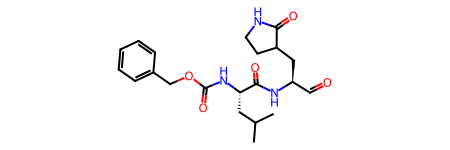

In [17]:
from rdkit import Chem
from rdkit.Chem.Draw import rdDepictor

rdDepictor.SetPreferCoordGen(True)
peptide = Chem.MolFromSmiles("CC(C)C[C@H](NC(=O)OCC1=CC=CC=C1)C(=O)N[C@@H](CC1CCNC1=O)C=O")
rdDepictor.Compute2DCoords(peptide)
peptide

In [1]:
import nglview
from openff.toolkit import ForceField, Molecule
from openff.units import unit

from openff.interchange import Interchange
from openff.interchange.components._packmol import UNIT_CUBE, pack_box
from openff.interchange.drivers import get_summary_data

In [65]:
molecules = [Molecule.from_smiles(smi) for smi in [ "CCN", "O", ]]#"CCN",]]
topology = pack_box(
    molecules=molecules,
    number_of_copies=[1,5],#,1],
    target_density=1000 * unit.kilogram / unit.meter**3,
    box_shape=UNIT_CUBE,
    center_solute="BRICK"
)
ff = ForceField("openff-2.3.0.offxml")
topology.box_vectors *= 10
interchange = ff.create_interchange(topology)
interchange.minimize()

/Users/jeffreywagner/micromamba/envs/demo/lib/python3.12/site-packages/openff/interchange/components/interchange.py:1119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, functools._lru_cache_wrapper) and obj.__module__.startswith("openff.interchange"):


In [69]:
w = interchange.visualize()

w.clear_representations()
#w.add_representation("cartoon", selection=":A", color="#990000")
#w.add_representation("cartoon", selection=":B", color="#4BD1C9")#"#FF7733")
w.add_representation(#"ball+stick",
                     #aspectRatio=1,
                     "licorice", 
    #bondScale=100, lineWidth=100, lineBuffer=100, 
    radius=.25,
                     selection=":A or :E or :F",
                     #color="#4BD1C9"
                    )
#w.add_representation("unitcell")
#w.add_spacefill(selection="water or ion", opacity=0.05)
w.camera="orthographic"
w

NGLWidget()